In [27]:
import pandas as pd

# 直接从网上载入真实的墨尔本房价数据(Colab 里不用下载文件)
url = "https://raw.githubusercontent.com/PatelKeviin/Melbourne-Housing-Market-and-Venues-Analysis/master/Melbourne_housing_FULL.csv"
df = pd.read_csv(url)

print("数据规模:", df.shape)   # (行数, 列数)
df.head()                      # 看前 5 行长什么样

数据规模: (34857, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [28]:
df.info()                                          # 每列的名字、类型、有多少非空值
df.describe()                                      # 数值列的统计摘要(均值、最大最小等)
df.isna().sum().sort_values(ascending=False)       # 每列缺多少个值,从多到少排

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

,0
BuildingArea,21115
YearBuilt,19306
Landsize,11810
Car,8728
Bathroom,8226
Bedroom2,8217
Lattitude,7976
Longtitude,7976
Price,7610
Regionname,3


In [29]:
import numpy as np

# 从原始数据复制一份来清洗,保留原始 df 不动(好习惯:出错了能回头对照)
clean = df.copy()

# 删掉成交价缺失的行 —— Price 是我们要分析/预测的"答案",绝不能凭空编造
clean = clean.dropna(subset=["Price"])

print("清洗后行数:", len(clean))
# 原始 Date 是 "3/09/2016" 这样的文本,电脑没法拿它算时间。转成真正的日期类型,
# 再提取出年份(后面分析"价格随时间怎么变"要用)
clean["Date"] = pd.to_datetime(clean["Date"], format="%d/%m/%Y")
clean["Year"] = clean["Date"].dt.year

print("日期范围:", clean["Date"].min().date(), "到", clean["Date"].max().date())

# 地块面积、建筑面积不可能是 0 —— 这些 0 是录入错误,不是真实值,先标成缺失(NaN)
for col in ["Landsize", "BuildingArea"]:
    clean[col] = clean[col].replace(0, np.nan)

print("Landsize 为 0 的行(应该变成 0 了):", (clean["Landsize"] == 0).sum())


# Bathroom(卫浴数)和 Car(车位数)有缺失,用"中位数"填补(对计数型字段稳妥,不受极端值影响)
clean["Bathroom"] = clean["Bathroom"].fillna(clean["Bathroom"].median())
clean["Car"] = clean["Car"].fillna(clean["Car"].median())

# 看看现在还剩哪些列有缺失
clean.isna().sum().sort_values(ascending=False).head(6)




# 加一个"每个房间多少钱"的简单价值指标(后面找"性价比"的区会用到)
clean["price_per_room"] = clean["Price"] / clean["Rooms"]

print("最终清洗结果:", clean.shape, "(行, 列)")
clean.head(3)

清洗后行数: 27247
日期范围: 2016-01-28 到 2018-03-17
Landsize 为 0 的行(应该变成 0 了): 0
最终清洗结果: (27247, 23) (行, 列)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,price_per_room
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0,2016,740000.000000
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0,2016,517500.000000
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,...,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0,2017,488333.333333


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [30]:
print("中位价: {:,.0f}".format(clean["Price"].median()))
print("平均价: {:,.0f}".format(clean["Price"].mean()))

中位价: 870,000
平均价: 1,050,173


In [31]:
# 按区分组,算每个区的「中位价」和「成交量」
suburb_stats = clean.groupby("Suburb").agg(
    median_price=("Price", "median"),
    sales=("Price", "size")
)

# 只看成交量 >= 50 的区(样本太少的中位数不可靠),再按中位价从高到低排
top = suburb_stats[suburb_stats["sales"] >= 50].sort_values("median_price", ascending=False)
top.head(8)

,median_price,sales
Suburb,,
Canterbury,2300000.0,85
Malvern,1995000.0,118
Middle Park,1880000.0,54
Camberwell,1835000.0,280
Balwyn,1810000.0,224
Albert Park,1810000.0,93
Brighton,1800000.0,317
Kew East,1754500.0,98


In [32]:
# Type 是缩写(h/u/t),先翻译成看得懂的名字
type_names = {"h": "House", "u": "Unit", "t": "Townhouse"}
clean["TypeName"] = clean["Type"].map(type_names)

clean.groupby("TypeName").agg(
    median_price=("Price", "median"),
    sales=("Price", "size")
).sort_values("median_price", ascending=False)

,median_price,sales
TypeName,,
House,1015000.0,18472
Townhouse,850000.0,2866
Unit,580000.0,5909


In [33]:
clean.groupby("Year").agg(
    median_price=("Price", "median"),
    sales=("Price", "size")
)

,median_price,sales
Year,,
2016,885000.0,8054
2017,875000.0,15519
2018,836500.0,3674


In [34]:
# 算各数值特征与 Price 的相关系数(范围 -1 到 1,绝对值越大关系越强)
cols = ["Price", "Rooms", "Bathroom", "Car", "Distance", "Landsize", "BuildingArea"]
clean[cols].corr()["Price"].sort_values(ascending=False)

,Price
Price,1.000000
Rooms,0.465238
Bathroom,0.395807
Car,0.162107
BuildingArea,0.101015
Landsize,0.020507
Distance,-0.211384


In [35]:
# 用「每个房间的平均价格」衡量性价比,越低越划算
value = clean.groupby("Suburb").agg(
    price_per_room=("price_per_room", "mean"),
    sales=("price_per_room", "size")
)
value[value["sales"] >= 50].sort_values("price_per_room").head(6)

,price_per_room,sales
Suburb,,
Melton South,140551.339286,56
Wyndham Vale,150820.283019,53
Meadow Heights,155748.054029,52
Roxburgh Park,156181.965894,74
Sunbury,162905.505952,140
Craigieburn,163657.543444,211


In [36]:
import matplotlib.pyplot as plt

# 设一个干净统一的风格(去掉多余边框,统一字号)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})
TEAL = "#2f6f7e"; CORAL = "#e07a5f"   # 主色 + 强调色,统一配色显得专业

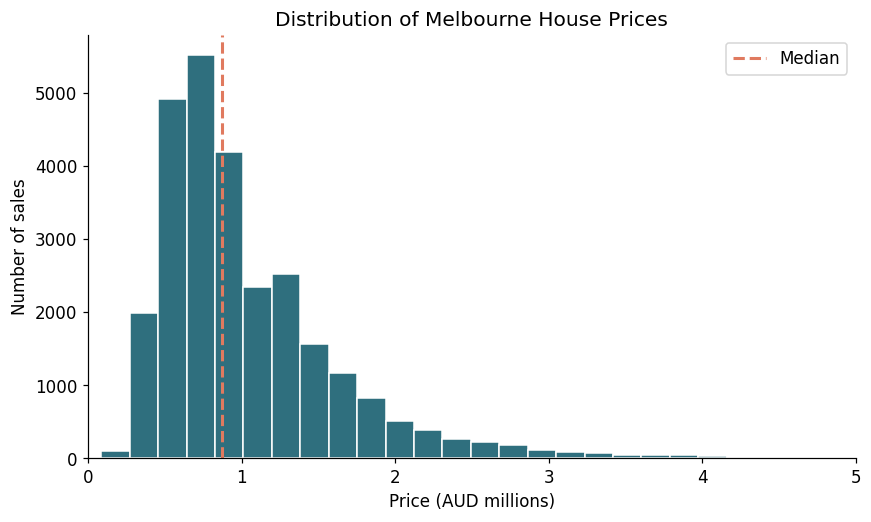

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(clean["Price"] / 1e6, bins=60, color=TEAL, edgecolor="white")
ax.axvline(clean["Price"].median() / 1e6, color=CORAL, ls="--", lw=2, label="Median")
ax.set_xlim(0, 5)
ax.set_title("Distribution of Melbourne House Prices")
ax.set_xlabel("Price (AUD millions)")
ax.set_ylabel("Number of sales")
ax.legend()
plt.show()

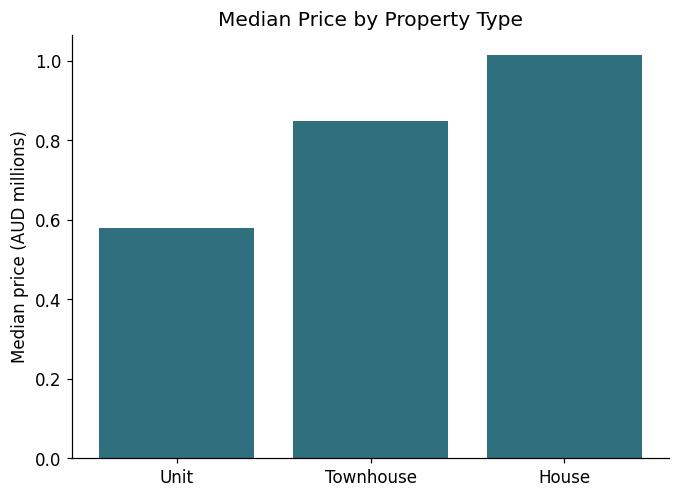

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))
type_median = clean.groupby("TypeName")["Price"].median().sort_values()
ax.bar(type_median.index, type_median.values / 1e6, color=TEAL)
ax.set_title("Median Price by Property Type")
ax.set_ylabel("Median price (AUD millions)")
plt.show()

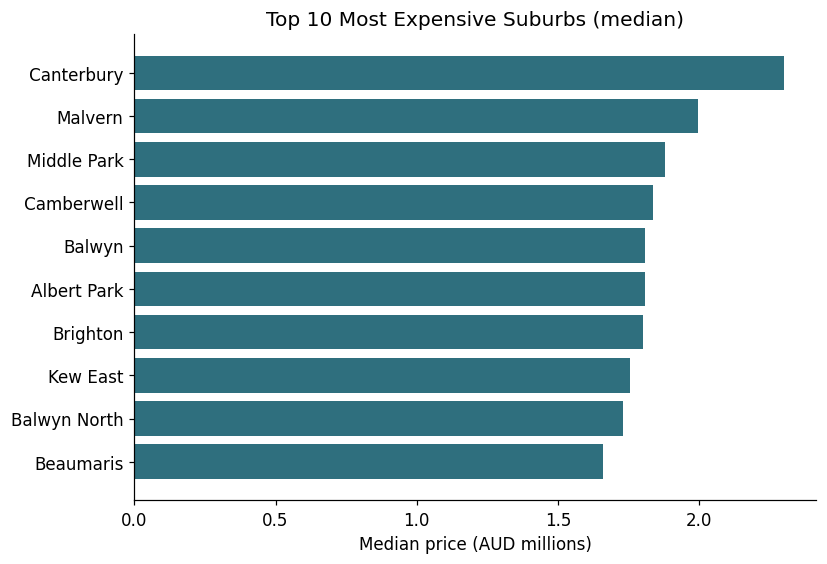

In [39]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ss = clean.groupby("Suburb").agg(m=("Price", "median"), n=("Price", "size"))
top = ss[ss["n"] >= 50].sort_values("m", ascending=False).head(10)
ax.barh(top.index[::-1], top["m"][::-1] / 1e6, color=TEAL)   # barh = 横向
ax.set_title("Top 10 Most Expensive Suburbs (median)")
ax.set_xlabel("Median price (AUD millions)")
plt.show()

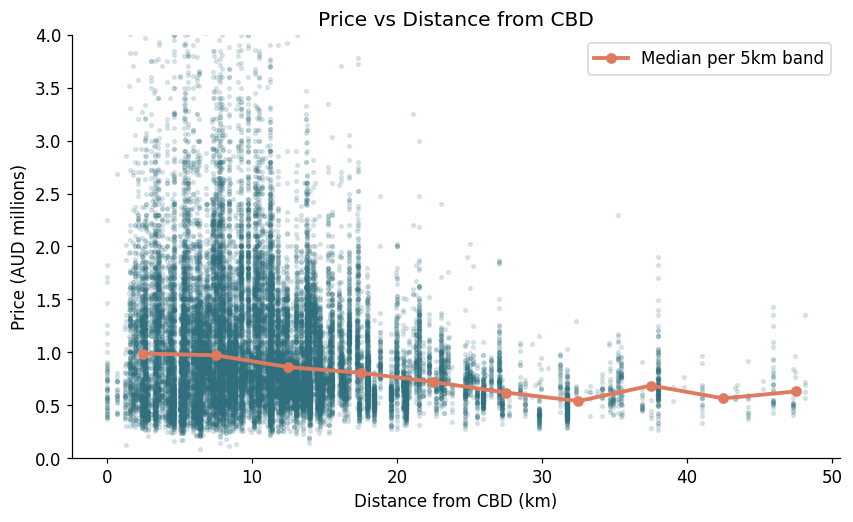

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
# 散点:每个点是一套房;透明度调低(alpha=0.15),否则几万个点会糊成一片
ax.scatter(clean["Distance"], clean["Price"] / 1e6, s=6, alpha=0.15, color=TEAL)

# 趋势线:每 5 公里算一次中位价,连成线,让规律更清楚
binned = clean.groupby(pd.cut(clean["Distance"], bins=range(0, 55, 5)), observed=True)["Price"].median()
centers = [iv.mid for iv in binned.index]
ax.plot(centers, binned.values / 1e6, color=CORAL, lw=2.5, marker="o", label="Median per 5km band")

ax.set_ylim(0, 4)
ax.set_title("Price vs Distance from CBD")
ax.set_xlabel("Distance from CBD (km)")
ax.set_ylabel("Price (AUD millions)")
ax.legend()
plt.show()

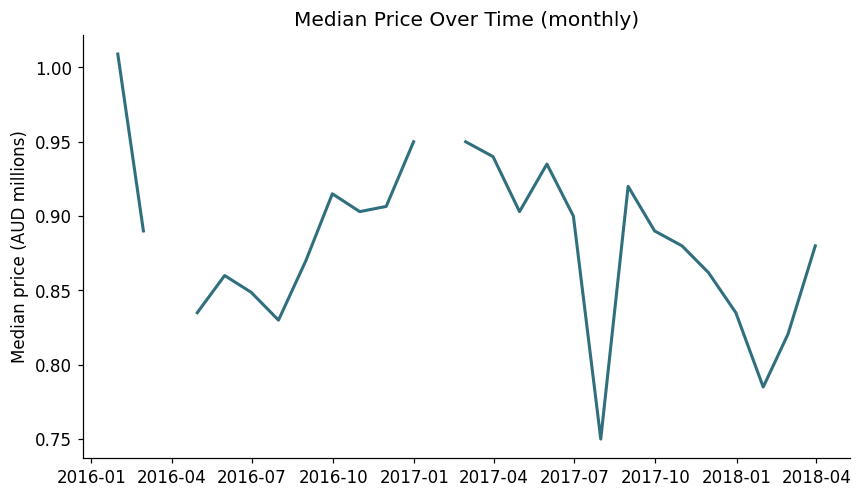

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))
# 按"月"重新汇总,算每月中位价(resample 是处理时间序列的利器)
monthly = clean.set_index("Date").resample("ME")["Price"].median()
ax.plot(monthly.index, monthly.values / 1e6, color=TEAL, lw=2)
ax.set_title("Median Price Over Time (monthly)")
ax.set_ylabel("Median price (AUD millions)")
plt.show()

In [42]:
# 选几个特征来预测价格。Type 和 Regionname 是文字,模型不认识文字,
# 要用 get_dummies 转成 0/1 列(这叫 one-hot 编码 / 独热编码)
features = ["Rooms", "Bathroom", "Car", "Distance", "Type", "Regionname"]

model_data = clean.dropna(subset=["Distance", "Regionname"])   # 去掉这两列极少数的缺失
model_data = pd.get_dummies(model_data[features + ["Price"]],
                            columns=["Type", "Regionname"], drop_first=True)

X = model_data.drop(columns="Price")   # 特征(输入)
y = model_data["Price"]                # 目标(要预测的答案)

print("特征数量:", X.shape[1])
X.head(3)

特征数量: 13


,Rooms,Bathroom,Car,Distance,Type_t,Type_u,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
1,2,1.0,1.0,2.5,False,False,False,True,False,False,False,False,False
2,2,1.0,0.0,2.5,False,False,False,True,False,False,False,False,False
4,3,2.0,0.0,2.5,False,False,False,True,False,False,False,False,False


In [43]:
from sklearn.model_selection import train_test_split

# 80% 用来训练模型,20% 留着考试(测试模型从没见过的数据)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("训练集:", len(X_train), " 测试集:", len(X_test))

训练集: 21795  测试集: 5449


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)              # 训练:让模型从训练集里"学规律"

predictions = model.predict(X_test)      # 用模型预测测试集

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print("R² (拟合优度):  {:.3f}".format(r2))
print("MAE (平均误差): {:,.0f} 澳元".format(mae))

R² (拟合优度):  0.566
MAE (平均误差): 284,463 澳元


In [45]:
# 线性回归的"系数"= 每个特征每增加 1 单位,价格平均变化多少
for f in ["Rooms", "Bathroom", "Car", "Distance"]:
    coef = model.coef_[list(X.columns).index(f)]
    print("{:10s} 每 +1: {:+,.0f} 澳元".format(f, coef))

Rooms      每 +1: +213,521 澳元
Bathroom   每 +1: +147,825 澳元
Car        每 +1: +42,053 澳元
Distance   每 +1: -42,346 澳元


In [46]:
# 造一套"假想房":3 房 2 卫 1 车位,距 CBD 10km,Southern Metropolitan 区
house = pd.DataFrame(columns=X.columns)
house.loc[0] = 0                                    # 先全填 0
house.loc[0, ["Rooms","Bathroom","Car","Distance"]] = [3, 2, 1, 10]
house.loc[0, "Regionname_Southern Metropolitan"] = 1

print("预测价格: {:,.0f} 澳元".format(model.predict(house)[0]))

预测价格: 1,593,890 澳元


In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("随机森林 R²:  {:.3f}".format(r2_score(y_test, rf_pred)))
print("随机森林 MAE: {:,.0f}".format(mean_absolute_error(y_test, rf_pred)))

随机森林 R²:  0.700
随机森林 MAE: 208,385


In [48]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

models = {
    "线性回归":     LinearRegression(),
    "岭回归":       Ridge(),
    "KNN":         KNeighborsRegressor(),
    "决策树":       DecisionTreeRegressor(random_state=42),
    "随机森林":     RandomForestRegressor(random_state=42, n_jobs=-1),
    "梯度提升":     GradientBoostingRegressor(random_state=42),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f"{name:8s} R² = {r2_score(y_test, m.predict(X_test)):.3f}")

线性回归     R² = 0.566
岭回归      R² = 0.566
KNN      R² = 0.674
决策树      R² = 0.609
随机森林     R² = 0.700
梯度提升     R² = 0.697
